In [4]:
!pip install fredapi
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from fredapi import Fred
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

In [5]:
fred = Fred(api_key='e956a3dbccd7d4f90be734f8d55b1d07')

series_ids = {
    'RSAFS': 'Retail Sales: All Food Services (Target)',
    'CPIAUCSL': 'Consumer Price Index',
    'UNRATE': 'Unemployment Rate',
    'FEDFUNDS': 'Federal Funds Rate',
    'PCE': 'Personal Consumption Expenditures',
    'DSPIC96': 'Real Disposable Personal Income'
}

data = pd.DataFrame()
for series_id in series_ids:
    data[series_id] = fred.get_series(series_id)

data.index = fred.get_series('RSAFS').index
data.dropna(inplace=True)

data.rename(columns=series_ids, inplace=True)
data.reset_index(inplace=True)
data.rename(columns={'index': 'ds', 'Retail Sales: All Food Services (Target)': 'y'}, inplace=True)

df = data.copy()

In [6]:
print("\n--- Data Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 7 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   ds                                 399 non-null    datetime64[ns]
 1   y                                  399 non-null    float64       
 2   Consumer Price Index               399 non-null    float64       
 3   Unemployment Rate                  399 non-null    float64       
 4   Federal Funds Rate                 399 non-null    float64       
 5   Personal Consumption Expenditures  399 non-null    float64       
 6   Real Disposable Personal Income    399 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 21.9 KB
None

--- Missing Values ---
ds                                   0
y                                    0
Consumer Price Index                 0
Unemployment Rate               

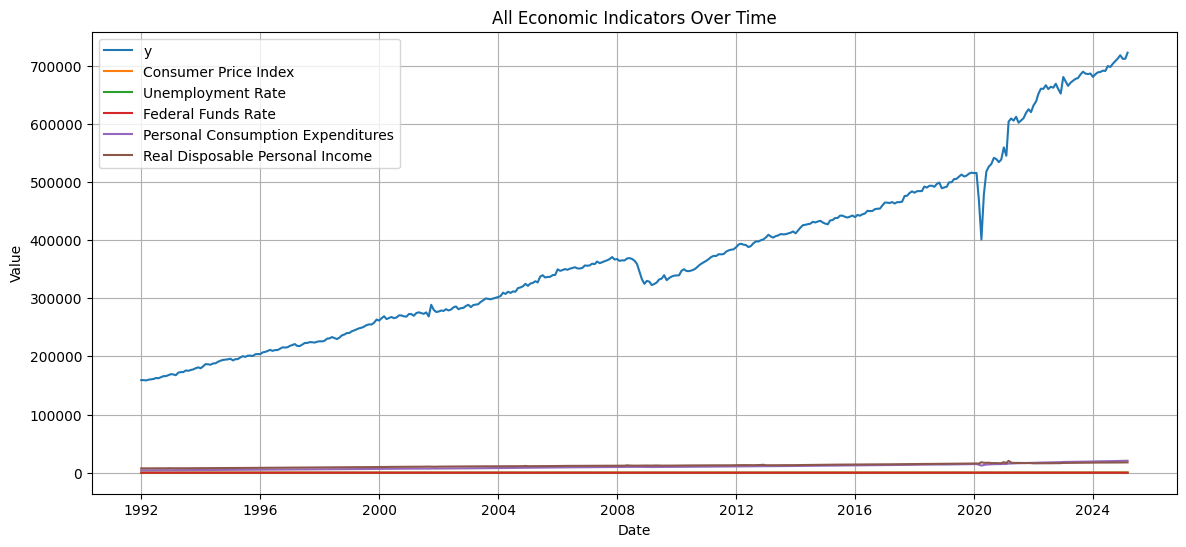

In [7]:
plt.figure(figsize=(14, 6))
for col in df.columns[1:]:
    plt.plot(df['ds'], df[col], label=col)
plt.title("All Economic Indicators Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

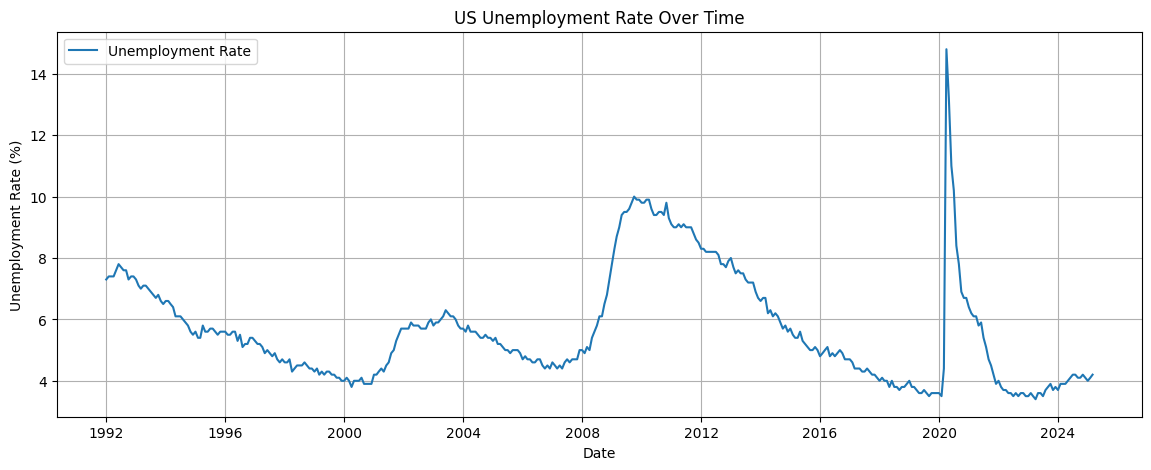

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['Unemployment Rate'], label='Unemployment Rate')
plt.title("US Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
fig = px.line(df, x='ds', y='Unemployment Rate', title='US Unemployment Rate Over Time (Interactive)')
fig.show()

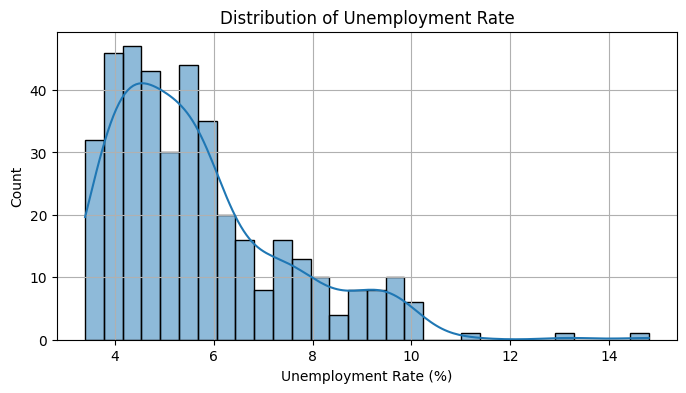

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Unemployment Rate'], kde=True, bins=30)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

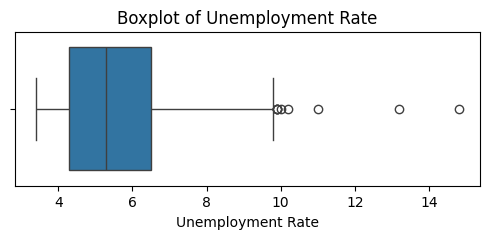

In [12]:
plt.figure(figsize=(6, 2))
sns.boxplot(x=df['Unemployment Rate'])
plt.title("Boxplot of Unemployment Rate")
plt.show()

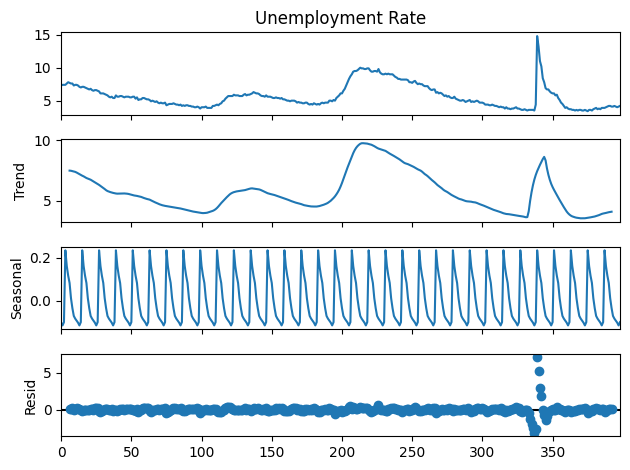

In [13]:
result = seasonal_decompose(df['Unemployment Rate'], model='additive', period=12)
result.plot()
plt.show()

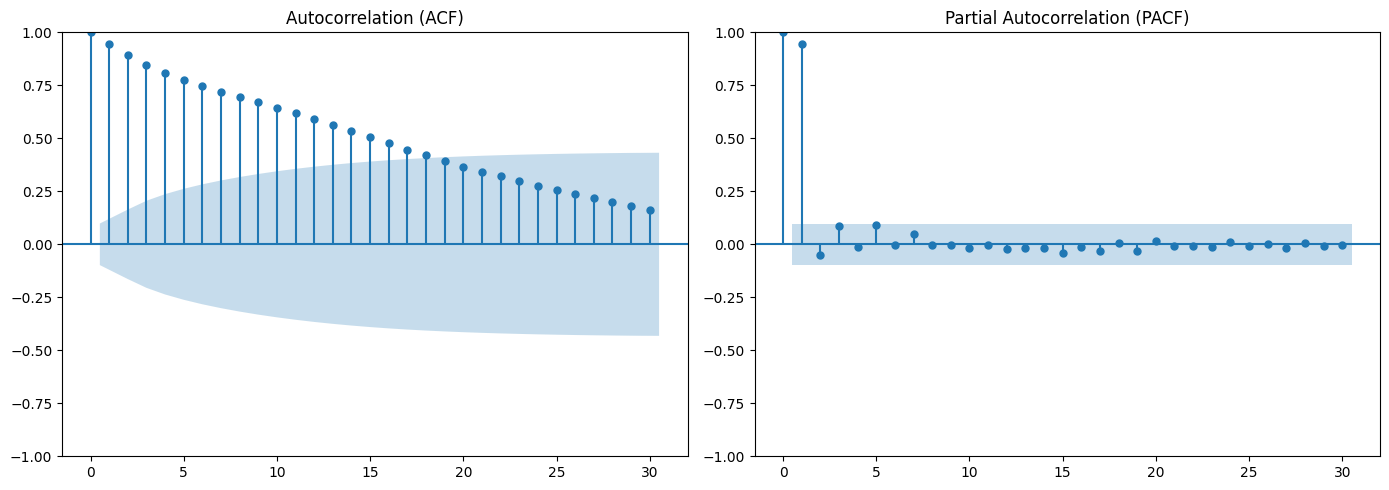

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df['Unemployment Rate'], lags=30, ax=axes[0])
plot_pacf(df['Unemployment Rate'], lags=30, ax=axes[1])
axes[0].set_title('Autocorrelation (ACF)')
axes[1].set_title('Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()

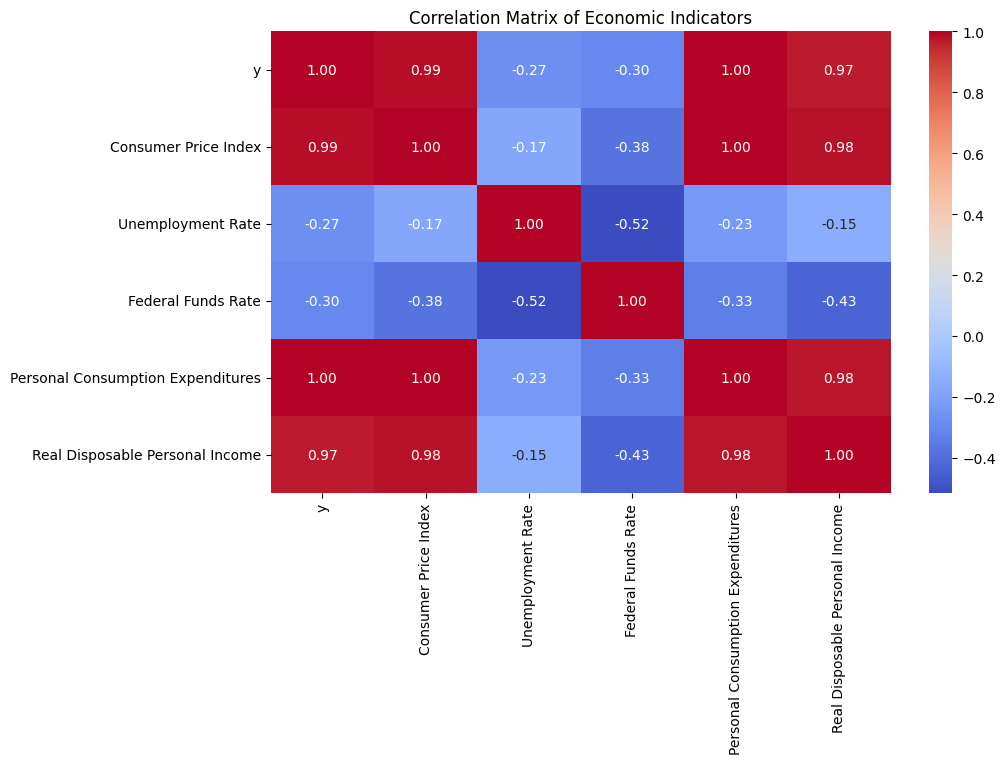

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['ds']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Economic Indicators")
plt.show()

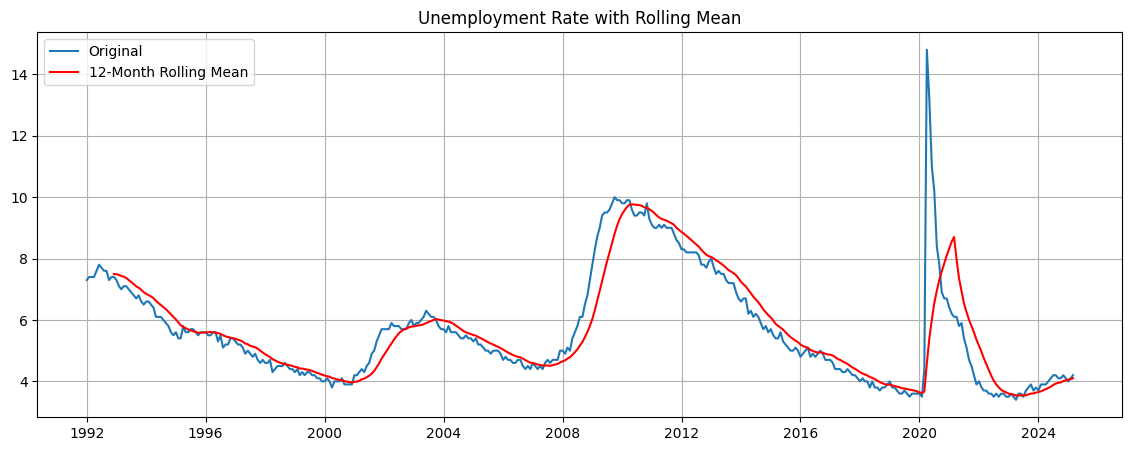

In [16]:
df['rolling_mean'] = df['Unemployment Rate'].rolling(window=12).mean()
plt.figure(figsize=(14, 5))
plt.plot(df['ds'], df['Unemployment Rate'], label='Original')
plt.plot(df['ds'], df['rolling_mean'], label='12-Month Rolling Mean', color='red')
plt.title("Unemployment Rate with Rolling Mean")
plt.legend()
plt.grid(True)
plt.show()

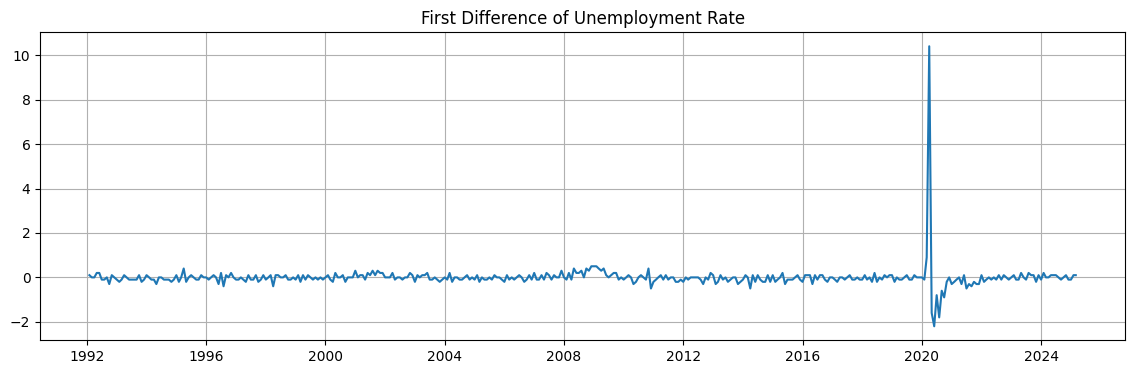

In [17]:
df['unrate_diff'] = df['Unemployment Rate'].diff()
plt.figure(figsize=(14, 4))
plt.plot(df['ds'], df['unrate_diff'], label='Change in Unemployment Rate')
plt.title("First Difference of Unemployment Rate")
plt.grid(True)
plt.show()

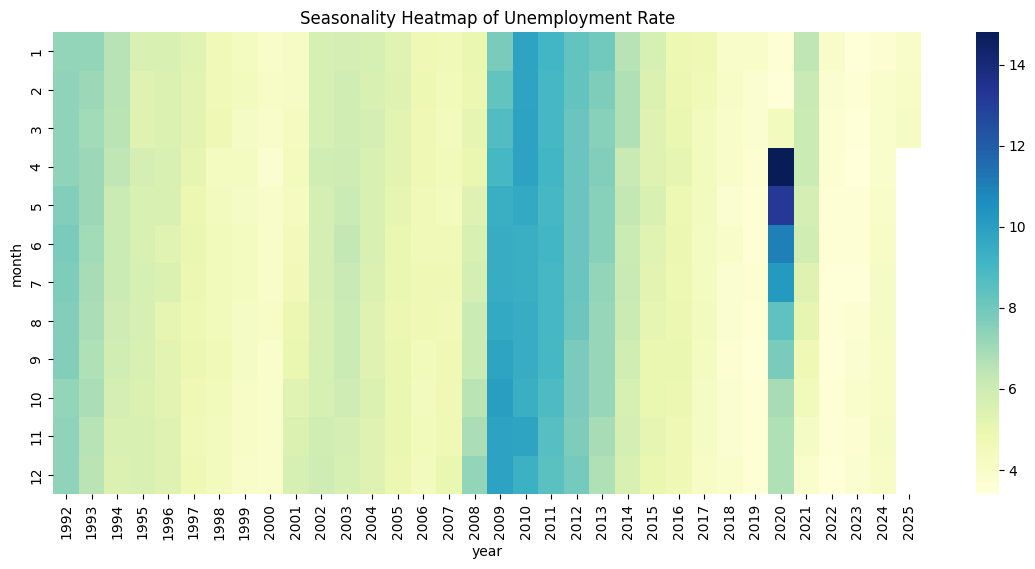

In [18]:
df['year'] = df['ds'].dt.year
df['month'] = df['ds'].dt.month
pivot = df.pivot_table(index='month', columns='year', values='Unemployment Rate')
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title("Seasonality Heatmap of Unemployment Rate")
plt.show()